In [ ]:
#| hide
from vlm_monitor.core import *

# vlm-monitor

> A second set of eyes.

### Installation

Install latest from the GitHub [repository][repo]:

```sh
$ pip install git+https://github.com/ForBo7/vlm-monitor.git
```


or from [pypi][pypi]


```sh
$ pip install vlm_monitor
```


[repo]: https://github.com/ForBo7/vlm-monitor
[docs]: https://ForBo7.github.io/vlm-monitor/
[pypi]: https://pypi.org/project/vlm-monitor/
[conda]: https://anaconda.org/ForBo7/vlm-monitor

### Documentation

Documentation can be found hosted on this GitHub [repository][repo]'s [pages][docs]. Additionally you can find package manager specific guidelines on [conda][conda] and [pypi][pypi] respectively.

[repo]: https://github.com/ForBo7/vlm-monitor
[docs]: https://ForBo7.github.io/vlm-monitor/
[pypi]: https://pypi.org/project/vlm-monitor/
[conda]: https://anaconda.org/ForBo7/vlm-monitor

## Example Usage

In [ ]:
from vlm_monitor.core import *

In [ ]:
!rm -rf test_db.db
db = init_db('test_db.db'); db

<Database <apsw.Connection "/app/data/vlm-monitor/nbs/test_db.db">>

In [ ]:
?init_db

````python
def init_db(
    path:str | pathlib.Path='db.db', # Path to database
)->Database:
    "Initialize a database and return it."
````

**File:** `~/vlm-monitor/vlm_monitor/core.py`; line: 35

**Type:** function

In [ ]:
dpath = Path('../../data/timss/'); dpath.ls()[:5]

[Path('../../data/timss/M-CZ3'), Path('../../data/timss/M-AU2'), Path('../../data/timss/M-CZ4'), Path('../../data/timss/M-JP2'), Path('../../data/timss/S-AU4')]

In [ ]:
dpaths = filter_paths(dpath.ls()).sorted(lambda o: (o.stem[:-1], o.stem[-1])); dpaths[:5]

[Path('../../data/timss/M-AU1'), Path('../../data/timss/M-AU2'), Path('../../data/timss/M-AU3'), Path('../../data/timss/M-AU4'), Path('../../data/timss/M-CZ1')]

In [ ]:
?filter_paths

````python
def filter_paths(
    paths:list, # List of paths to filter
    chs:str='.', # Characters to check for in the component
    comp:str='stem', # Path attribute to inspect (e.g. 'stem', 'name')
    negate:bool=True, # If True, exclude paths whose `comp` contains `chs`; if False, keep only those
)->list: # Filtered list of paths
    "Filter paths by whether a path component contains specified characters."
````

**File:** `~/vlm-monitor/vlm_monitor/core.py`; line: 63

**Type:** function

In [ ]:
populate_db(db, dpaths)

HTML(
<style>
    progress { appearance: none; border: none; border-radius: 4px; width: 300px;
        height: 20px; vertical-align: middle; background: #e0e0e0; }

    progress::-webkit-progress-bar { background: #e0e0e0; border-radius: 4px; }
    progress::-webkit-progress-value { background: #2196F3; border-radius: 4px; }
    progress::-moz-progress-bar { background: #2196F3; border-radius: 4px; }

    progress:not([value]) {
        background: repeating-linear-gradient(45deg, #7e7e7e, #7e7e7e 10px, #5c5c5c 10px, #5c5c5c 20px); }

    progress.progress-bar-interrupted::-webkit-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-webkit-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted { background: #F44336; }    

    table.fastprogress { border-collapse: collapse; margin: 1em 0; font-size: 0.9em; }
    table.fastprogress th, table.fastprogress td { padding: 8px 12px; border: 1px solid #ddd; text-align: left; }
    table.fastprogress thead tr { background: #f8f9fa; font-weight: bold; }
    table.fastprogress tbody tr:nth-of-type(even) { background: #f8f9fa; }
</style>
)

<div></div>

In [ ]:
?populate_db

````python
def populate_db(
    db:Database, # Database to populate
    paths:list, # List of video directories
    sample_rate:int=1, # Sampling rate for frames
    trans_suffix:str='txt', # Transcript file suffix
)->None:
    "Populate video and frame tables from a list of video directories."
````

**File:** `~/vlm-monitor/vlm_monitor/core.py`; line: 122

**Type:** function

In [ ]:
len(db.t.video()), len(db.t.frame())

(52, 149880)

In [ ]:
s = session(system='Reply concisely', model='bytedance-seed/seed-2.0-mini', vendor_name='openrouter', reasoning_effort='high')

In [ ]:
?session

````python
def session(
    msgs:list | None=None, model:str='', max_think:float=inf, usage:bool=True, display:bool=True, **kwargs
):
    "Create a stream partial with preset model/kwargs."
````

**File:** `~/vlm-monitor/vlm_monitor/core.py`; line: 204

**Type:** function

In [ ]:
from PIL import Image

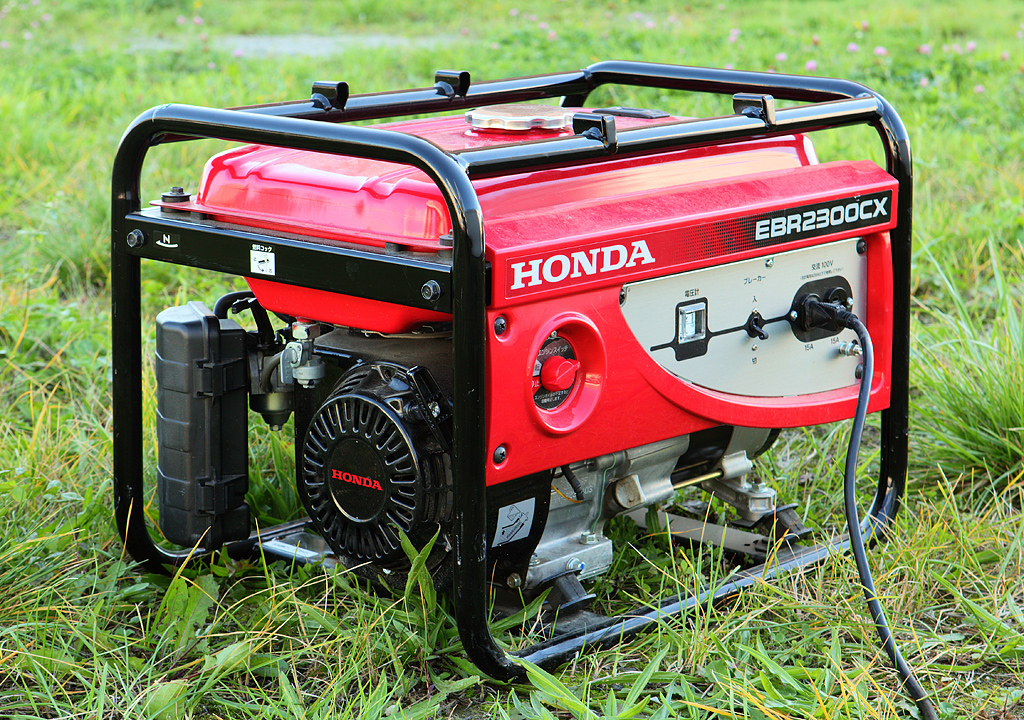

In [ ]:
Image.open('test.jpg')

In [ ]:
r = await s([user('what do your elf eyes see?', img2b64(Path('test.jpg')))]); r

Elf eyes spot this crisp Honda EBR2300CX portable gas generator, nestled in sun-warmed wild grass dotted with tiny pink clover blooms. I notice the black roll-cage frame, the plugged-in power cord, the Japanese-labeled control panel with its voltage meter and circuit breaker, and the branded recoil starter on the engine side.

<details markdown='1'>

- model: `bytedance-seed/seed-2.0-mini`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=1336, completion_tokens=399, total_tokens=1735, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=326, raw={'prompt_tokens': 1336, 'completion_tokens': 399, 'total_tokens': 1735, 'cost': 0.0002932, 'is_byok': False, 'prompt_tokens_details': {'cached_tokens': 0, 'cache_write_tokens': 0, 'audio_tokens': 0, 'video_tokens': 0}, 'cost_details': {'upstream_inference_cost': 0.0002932, 'upstream_inference_prompt_cost': 0.0001336, 'upstream_inference_completions_cost': 0.0001596}, 'completion_tokens_details': {'reasoning_tokens': 326, 'image_tokens': 0, 'audio_tokens': 0}})`

</details>

In [ ]:
?user

````python
def user(
    txt:str, img:str | None=None
)->Msg:
    "Build a user message with optional image."
````

**File:** `~/vlm-monitor/vlm_monitor/core.py`; line: 147

**Type:** function

In [ ]:
?img2b64

````python
def img2b64(
    path:Path
)->str:
    "Encode an image file as a base64 data URL."
````

**File:** `~/vlm-monitor/vlm_monitor/core.py`; line: 197

**Type:** function

In [ ]:
vlm_prompt = 'Tell me what your elf eyes see. In particular, pay attention to anything that looks green.'

In [ ]:
vid = db.t.video[1].id; vid

1

In [ ]:
o = await deploy_run(vid, db, s, vlm_prompt, prompt_type='default', stop=300, step=3, cache=True, n_workers=20, pause=0.1, max_retries=2)

!! Using cache


╭─ Run #1 ═══════════════════════════════╮
│ Model    bytedance-seed/seed-2.0-mini
│ Start    0
│ Stop     300
│ Step     3
│ Frames   100
│ Cache    True
│ Time     13:53:36
╰──────────────────────────────────────────────╯


1/100

2/100

3/100

...

97/100

98/100

99/100

100/100

╭─ Run #1 Complete ═════════════════════╮
│ Finish   13:54:09
│ Elapsed  0:00:33
│ Cost     $0.0331 (HKD 0.26)
╰──────────────────────────────────────────────╯


In [ ]:
?deploy_run

````python
async def deploy_run(
    video_id:int, db:Database, session:Callable, prompt:str, prompt_type:str, start:int=0, stop:int | None=None,
    step:int=1, cache:bool=False, include_subs:bool=True, n_workers:int=8, pause:float=3, max_retries:int=2
)->Run:
    "Run a single prompt across a range of frames, storing results in the database."
````

**File:** `~/vlm-monitor/vlm_monitor/core.py`; line: 307

**Type:** function

In [ ]:
summary_prompt = 'You will receive a series of individual frame descriptions. You need to combine these individual descriptions together into a coherent narrative.'

In [ ]:
summary = await summarize_run(db, s, sys_prompt=summary_prompt, run_id=o.id, window_sec=60, step=1, cache=True)

In [ ]:
?summarize_run

````python
async def summarize_run(
    db:Database, session:Callable, sys_prompt:str, run_id:int | None=None, video_id:int | None=None,
    window_sec:int=300, step:int=1, cache:bool=False
)->str:
    "Summarize a single run or all frames for a video in rolling windows."
````

**File:** `~/vlm-monitor/vlm_monitor/core.py`; line: 424

**Type:** function

In [ ]:
print(summary[:500])

[1–178s] ### Cohesive Narrative of the Classroom Footage
What unfolds across the timed footage is a detailed tour of multiple school classroom settings, viewed through the sharp, observant lens of elven vision, with green as the recurring standout accent color.

Opening in the first 25 seconds, the scene is a quiet, empty classroom: bright green padded plastic chair seats and backs pair with dark-topped student desks clustered across the room, with faint green trim lining the left-side windows. 


## Developer Guide

This library is built using [nbdev](https://nbdev.fast.ai/), a way to create dlightful software with Jupyter Notebooks. Learn how to get started with nbdev [here](https://nbdev.fast.ai/tutorials/tutorial.html).

### Install vlm_monitor in Development mode

```sh
# make sure vlm_monitor package is installed in development mode
$ pip install -e .

# make changes under nbs/ directory
# ...

# compile to have changes apply to vlm_monitor
$ nbdev-prepare
```

After cloning, be usre to run [`nbdev-install-hooks`](http://nbdev.fast.ai/tutorials/tutorial.html#install-hooks-for-git-friendly-notebooks) in your terminal to install Jupyter and git hooks. These hooks clean, trust, and fix merge conflicts in notebooks.

Anytime you make changes to the repo, run [`nbdev-prepare`](http://nbdev.fast.ai/tutorials/tutorial.html#prepare-your-changes).

## Credit

This library is built using [nbdev](https://nbdev.fast.ai/) on [SolveIt](https://solve.it.com/), both by [Answer.AI]. Other libraries used include:
- [fastcore](https://github.com/AnswerDotAI/fastcore)
- [fastlite](https://github.com/AnswerDotAI/fastlite)
- [fastllm](https://github.com/AnswerDotAI/fastllm)
- [aidialog](https://github.com/AnswerDotAI/aidialog/)
- [fastprogress](https://github.com/AnswerDotAI/fastprogress)
- [pycachy](https://github.com/AnswerDotAI/cachy)
- [tiktoken](https://github.com/openai/tiktoken)